In [52]:
import copy
import cv2
import glob
import math
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import os
import pandas as pd
import seaborn as sns
from astropy.io import fits
import torch
from torch.utils.data import Dataset
from torchmetrics import Dice
from torchmetrics import Dice, JaccardIndex
import segmentation_models_pytorch as smp

In [53]:
hiperparametros = {'nombre_notebook': 'Evaluation_NISP_H_1000imgs_v10_log_no_aug.ipynb',
                    'nombre_experimento' : 'Evaluation_NISP_H_1000imgs_v10_log_no_aug',
                    'nombre_mejor_modelo_entrenado' : 'NISP_H_1000imgs_v10_log_no_aug',
                    'device' : torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
                    'ruta_galaxias' : 'galaxies_test_NISP_H/galaxy_and_stream_convolved*.fits',
                    'ruta_mascaras' : '../masks_train_NISP_H/mask_',
                    'ancho_imagen_original' : 200,
                    'alto_imagen_original' : 200,
                    'ancho_imagen_deseado' : 224,
                    'alto_imagen_deseado' : 224}

In [54]:
def get_galaxy_number(galaxy_name:str):
    return os.path.basename(galaxy_name).split('_')[4]

def get_galaxy_magnitude(galaxy_name:str):
    return os.path.basename(galaxy_name).split('_')[5]

def normalize_01(inp: np.ndarray):
    """Squash image input to the value range [0, 1] (no clipping)"""
    inp_out = (inp - np.min(inp)) / np.ptp(inp)
    return inp_out

def imagen_logaritmica(img: np.ndarray)->np.ndarray:
    """
    Escalamos de forma logarítmica la imagen para aumentar el contraste
    """
    img_log = np.log(img, where=(img>0))
    valor_minimo = np.min(img_log)
    np.putmask(img_log, img!=0, img_log+abs(valor_minimo))
    return img_log

In [55]:
def get_mag_stream_percentage(galaxy_number):
    
    path_catalogs_folder = "../../dataset_generation/catalogs_for_checking" 
    path_catalog = os.path.join(path_catalogs_folder, "stream_characteristics_"+str(galaxy_number)+".txt")
    df = pd.read_csv(path_catalog, delimiter=r"\s+", engine="python")
    mag_bulge = df.iloc[1, 3]
    mag_disk = df.iloc[1, 8]
    mag_stream = df.iloc[1, 13]
    zeropoint= 30.132  # For VIS, (For NISP is 30)
    flux_bulge = 10**((mag_bulge-zeropoint)/(-2.5)) 
    flux_disk = 10**((mag_disk-zeropoint)/(-2.5))
    flux_galaxy = flux_bulge + flux_disk
    flux_stream = 10**((mag_stream-zeropoint)/(-2.5)) 
    mag_stream_percentage = flux_stream/flux_galaxy
    mag_stream_percentage_rounded_up = math.ceil(mag_stream_percentage*100)
    if mag_stream_percentage_rounded_up == 6:
        mag_stream_percentage_rounded_up = 5
    print("MAG_STREAM_PERCENTAGE: " + str(mag_stream_percentage) + "->" + str(mag_stream_percentage_rounded_up)+ "%")
    return mag_stream_percentage_rounded_up

In [56]:
class MyDataset(Dataset):
    """
    Dataset básico sin ningún tipo de augmentation
    """
    def __init__(self, galaxias_con_colas_de_marea, transform=None):
        """
        Constructor del dataset
        @param galaxias_con_colas_de_marea: Lista de rutas a los ficheros que contienen los datos de las galaxias
        """
        self.galaxias_con_colas_de_marea = galaxias_con_colas_de_marea
        self.transform=transform

    def __getitem__(self, index):
        #Abrimos la imagen de la galaxia con cola de marea
        ruta = self.galaxias_con_colas_de_marea[index]
        magnitud_real = get_galaxy_magnitude(ruta)
        
        galaxy_fits = fits.open(self.galaxias_con_colas_de_marea[index])
        x = galaxy_fits[0].data.astype(np.float32)
        #Abrimos la mascara correspondiente a la imagen
        numero_galaxia = get_galaxy_number(self.galaxias_con_colas_de_marea[index])
        magnitud_galaxia = get_galaxy_magnitude(self.galaxias_con_colas_de_marea[index])
        mag_stream_percentage = get_mag_stream_percentage(numero_galaxia)

        y = np.array(cv2.imread(hiperparametros['ruta_mascaras']+str(numero_galaxia)+"_"+str(magnitud_galaxia)+".png",0)).astype(np.float32)
        #x = normalize_01(x)
        x_tensor_visualizar = copy.deepcopy(x)
        x = imagen_logaritmica(x)

        x = normalize_01(x)
        # Assuming 'input_item' is your input image
        x = cv2.resize(x, (hiperparametros['ancho_imagen_deseado'], hiperparametros['alto_imagen_deseado']))
        y = cv2.resize(y, (hiperparametros['ancho_imagen_deseado'], hiperparametros['alto_imagen_deseado']))
        if(self.transform is not None):
            augmented = self.transform(image=x, mask=y)
            x_tensor= augmented["image"]
            y_tensor= augmented["mask"].long()
        else:
            x_tensor = torch.from_numpy(x).float()
            x_tensor=torch.unsqueeze(x_tensor, dim=0)
            y_tensor = torch.from_numpy(y).long()
        
        #Hacemos reshape de los tensores
        y_tensor=torch.unsqueeze(y_tensor, dim=0)
        return x_tensor, y_tensor, ruta, magnitud_real, x_tensor_visualizar, mag_stream_percentage
    
    def __len__(self):
        """
        Devuelve la longitud del dataset
        """
        return len(self.galaxias_con_colas_de_marea)

In [57]:
dice = Dice(num_classes=2, average='macro', ignore_index=0)
iou = JaccardIndex(task='multiclass', num_classes=2, average='none', ignore_index=0)
imagenes_test = glob.glob(hiperparametros['ruta_galaxias'])
imagenes_test.sort()
#Cargamos el dataset de test
test_dataset= MyDataset(imagenes_test)
print("Number of valid images: " + str(len(imagenes_test)))
device = hiperparametros['device']
#dice.to(device)

Number of valid images: 1741


In [58]:
unet = smp.Unet(
    encoder_name="resnet18",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=2,                      # model output channels (number of classes in your dataset)
)

In [59]:
#Cargamos el modelo previamente entrenado
ruta_modelo = hiperparametros['nombre_mejor_modelo_entrenado']
mejor_modelo = unet
mejor_modelo.load_state_dict(torch.load(ruta_modelo))
mejor_modelo.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [60]:
len(test_dataset)

1741

In [61]:
resultados_dice = {
    '0.05':[],
    '0.1':[],
    '0.15':[],
    '0.2':[],
    '0.25':[],
    '0.4':[],
    '0.6':[],
    '0.8':[],
    '1':[],
}
resultados_iou = {
    '0.05':[],
    '0.1':[],
    '0.15':[],
    '0.2':[],
    '0.25':[],
    '0.4':[],
    '0.6':[],
    '0.8':[],
    '1':[],
}

dice_results_redshift_with_mag_stream_percentage = {
    '0.05':{1:[],2:[],3:[],4:[],5:[],},
    '0.1':{1:[],2:[],3:[],4:[],5:[],},
    '0.15':{1:[],2:[],3:[],4:[],5:[],},
    '0.2':{1:[],2:[],3:[],4:[],5:[],},
    '0.25':{1:[],2:[],3:[],4:[],5:[],},
    '0.4':{1:[],2:[],3:[],4:[],5:[],},
    '0.6':{1:[],2:[],3:[],4:[],5:[],},
    '0.8':{1:[],2:[],3:[],4:[],5:[],},
    '1':{1:[],2:[],3:[],4:[],5:[],},
}

iou_results_redshift_with_mag_stream_percentage = {
    '0.05':{1:[],2:[],3:[],4:[],5:[],},
    '0.1':{1:[],2:[],3:[],4:[],5:[],},
    '0.15':{1:[],2:[],3:[],4:[],5:[],},
    '0.2':{1:[],2:[],3:[],4:[],5:[],},
    '0.25':{1:[],2:[],3:[],4:[],5:[],},
    '0.4':{1:[],2:[],3:[],4:[],5:[],},
    '0.6':{1:[],2:[],3:[],4:[],5:[],},
    '0.8':{1:[],2:[],3:[],4:[],5:[],},
    '1':{1:[],2:[],3:[],4:[],5:[],},
}


# Without photos
ancho = hiperparametros['ancho_imagen_deseado']
alto =hiperparametros['alto_imagen_deseado']
mejor_modelo.eval()
pasos_test=0
dice_medio_test=0
iou_medio_test = 0
zp = 30.137
pix_scale = 0.1
for i in range(int(len(test_dataset))):
    item_dataset = test_dataset.__getitem__(i)
    item_x = item_dataset[0].reshape((1,1,ancho,alto)).cpu().detach().squeeze().numpy()
    item_label = item_dataset[1].reshape((1,1,ancho,alto)).cpu().detach().squeeze().numpy()
    #Si la máscara es vacía no intentamos segmentarla, para que no cuente en el dice
    if(np.count_nonzero(item_label)!=0):

        #Obtenemos predicción de la red
        prediccion_item_tensor = mejor_modelo(item_dataset[0].reshape((1,1,ancho,alto)).to(device)).cpu().detach().squeeze()   
        mascara_predicha = torch.argmax(prediccion_item_tensor, dim=0).numpy()
        valor_dice = dice(torch.from_numpy(item_label), torch.from_numpy(mascara_predicha))
        valor_iou = iou(torch.from_numpy(item_label), torch.from_numpy(mascara_predicha))[1]
        magnitud = item_dataset[3]
        mag_stream_percentage = item_dataset[5]
        
        print("Path: "+item_dataset[2]+ "\nMagnitud: "+ magnitud + ", Dice: "+str(round(valor_dice.item(), 4))+" Iou :" + str(round(valor_iou.item(), 4)))
        resultados_dice[magnitud].append(valor_dice.item())
        resultados_iou[magnitud].append(valor_iou.item())
        # Insert data to dicts for plotting stats later
        dice_results_redshift_with_mag_stream_percentage[magnitud][mag_stream_percentage].append(valor_dice.item())
        iou_results_redshift_with_mag_stream_percentage[magnitud][mag_stream_percentage].append(valor_iou.item())

        dice_medio_test += valor_dice.item()
        iou_medio_test += valor_iou.item()
        pasos_test += 1
        #Mostramos imagen, mascara y mascara predicha
        item_x = cv2.resize(item_x.astype(np.float32), (hiperparametros['ancho_imagen_original'], hiperparametros['alto_imagen_original']), interpolation = cv2.INTER_NEAREST)     
        item_label = cv2.resize(item_label.astype(np.uint8), (hiperparametros['ancho_imagen_original'], hiperparametros['alto_imagen_original']), interpolation = cv2.INTER_NEAREST)   
        mascara_predicha = cv2.resize(mascara_predicha.astype(np.float32), (hiperparametros['ancho_imagen_original'], hiperparametros['alto_imagen_original']), interpolation = cv2.INTER_NEAREST)     
        #fig, (axs0, axs1, axs2) = plt.subplots(1,3, figsize = (15,15))
        #axs0.imshow(item_x, interpolation='none', origin="lower")
        #axs1.imshow(item_label, interpolation='none', origin="lower")
        #axs2.imshow(mascara_predicha, interpolation='none', origin="lower")
        #plt.show()
        #guardar_imagen_plt(item_x, "item_x", i)
        #guardar_imagen_plt(item_label, "item_label", i)
        #guardar_imagen_plt(mascara_predicha, "mascara_predicha", i)


MAG_STREAM_PERCENTAGE: 0.03019772040089842->4%
MAG_STREAM_PERCENTAGE: 0.03019772040089842->4%
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.15_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.15, Dice: 0.0 Iou :0.0
MAG_STREAM_PERCENTAGE: 0.03019772040089842->4%
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.1_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.1, Dice: 0.0 Iou :0.0
MAG_STREAM_PERCENTAGE: 0.03019772040089842->4%
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.25_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.25, Dice: 0.0 Iou :0.0
MAG_STREAM_PERCENTAGE: 0.03019772040089842->4%
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.2_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.2, Dice: 0.0 Iou :0.0
MAG_STREAM_PERCENTAGE: 0.03019772040089842->4%
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.4_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.4, Dice: 0.0 Iou :0.0
MAG_STREAM_PERCENTAGE: 0

In [62]:
dice_test_medio_total=dice_medio_test/pasos_test
print("Dice_medio_total="+str(dice_test_medio_total))

Dice_medio_total=0.08179409994918162


In [63]:
iou_test_medio_total=iou_medio_test/pasos_test
print("IOU_medio_total="+str(iou_test_medio_total))

IOU_medio_total=0.26310093634021586


In [64]:
# Filtrar NaNs y calcular la media para resultados_dice
dices_medios_por_magnitud = [np.mean([x for x in lista if not np.isnan(x)]) for lista in resultados_dice.values()]
print(dices_medios_por_magnitud)
# Filtrar NaNs y calcular la media para resultados_iou
ious_medios_por_magnitud = [np.mean([x for x in lista if not np.isnan(x)]) for lista in resultados_iou.values()]
print(ious_medios_por_magnitud)

[0.08987960840133413, 0.12282233379428854, 0.1269869454707836, 0.10354156437806966, 0.10384488599029956, 0.06008585702769364, 0.041003801913133686, 0.03258205404666465, 0.02440120279788971]
[0.3502828801461196, 0.40517115942831783, 0.4128320509670702, 0.3431835789233446, 0.3082998318160758, 0.17941759404125093, 0.12689255209905762, 0.08672665963022727, 0.062305296135840016]


/tmp/ipykernel_244577/1810617054.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados_dice.keys()), y=dices_medios_por_magnitud, palette=bar_colors)


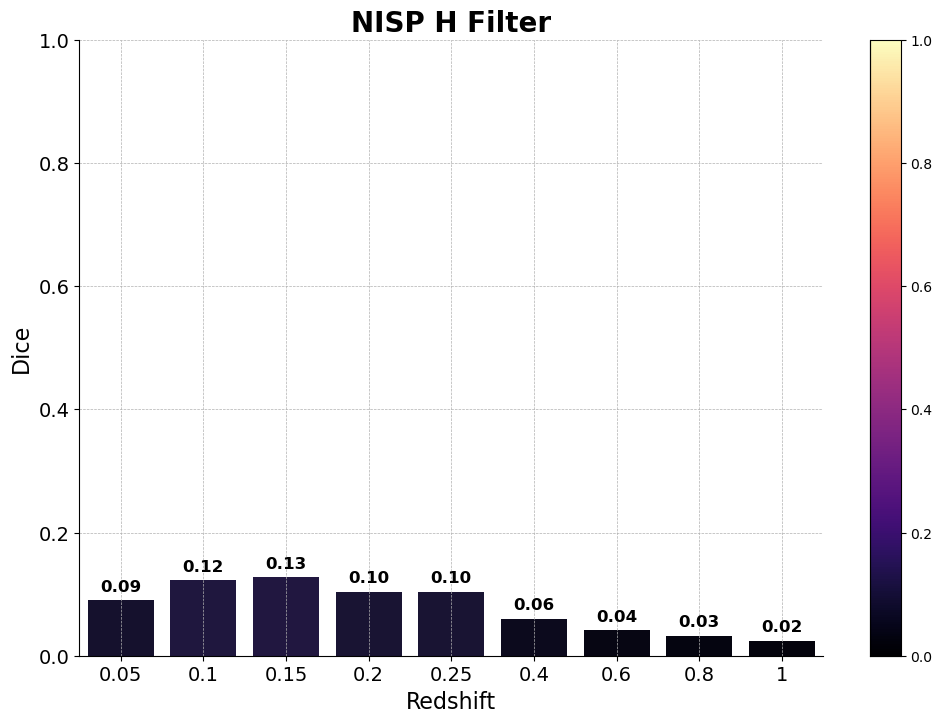

In [65]:
# Crear una paleta de colores en función de los valores alcanzados, normalizada entre 0 y 1
norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap="magma", norm=norm)
sm.set_array([])

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))

# Crear el gráfico de barras
bar_colors = [sm.to_rgba(valor) for valor in dices_medios_por_magnitud]
ax = sns.barplot(x=list(resultados_dice.keys()), y=dices_medios_por_magnitud, palette=bar_colors)

# Ajustar los límites del eje y entre 0 y 1
ax.set_ylim(0, 1)

# Añadir etiquetas con los valores sobre las barras
for i, valor in enumerate(dices_medios_por_magnitud):
    ax.text(i, valor + 0.01, f'{valor:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Añadir un título y ajustar etiquetas
plt.title('NISP H Filter', fontsize=20, fontweight='bold')
plt.xlabel('Redshift', fontsize=16)
plt.ylabel('Dice', fontsize=16)

# Ajustar el tamaño de las etiquetas de los ejes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Añadir líneas de cuadrícula
ax.grid(True, linestyle='--', linewidth=0.5)

# Añadir la barra de color (colorbar)
cbar = plt.colorbar(sm, ax=ax)

# Mejorar el diseño general
sns.despine()
#plt.savefig('images_paper/vis_filter_dice.png', dpi=300, bbox_inches='tight')
# Mostrar el gráfico
plt.show()

/tmp/ipykernel_244577/3070687478.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados_dice.keys()), y=ious_medios_por_magnitud, palette=bar_colors)


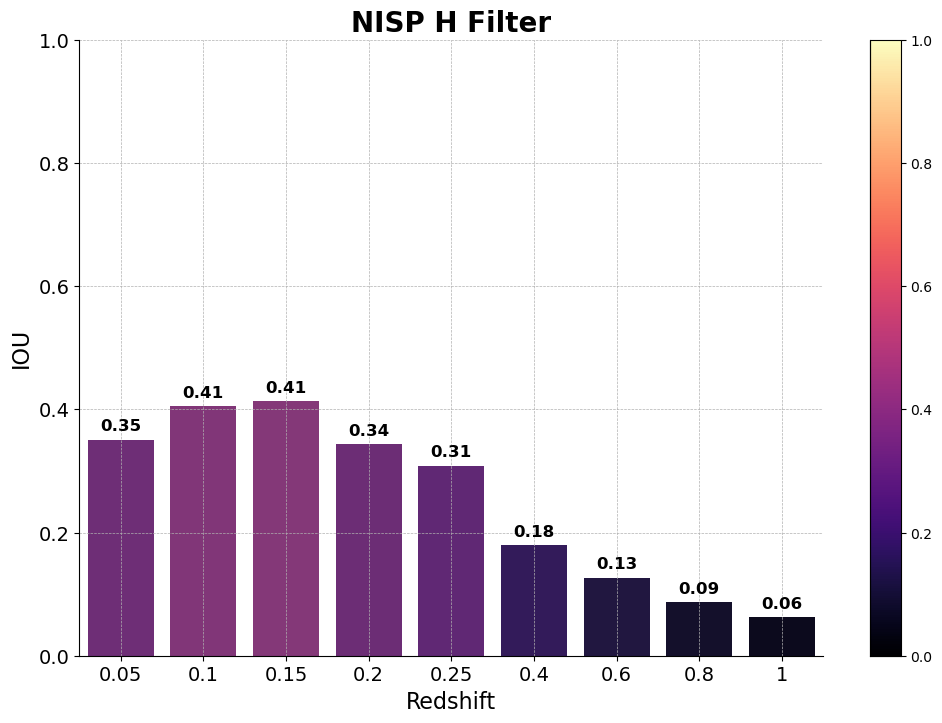

In [66]:
# Crear una paleta de colores en función de los valores alcanzados, normalizada entre 0 y 1
norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap="magma", norm=norm)
sm.set_array([])

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))

# Crear el gráfico de barras
bar_colors = [sm.to_rgba(valor) for valor in ious_medios_por_magnitud]
ax = sns.barplot(x=list(resultados_dice.keys()), y=ious_medios_por_magnitud, palette=bar_colors)

# Ajustar los límites del eje y entre 0 y 1
ax.set_ylim(0, 1)

# Añadir etiquetas con los valores sobre las barras
for i, valor in enumerate(ious_medios_por_magnitud):
    ax.text(i, valor + 0.01, f'{valor:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Añadir un título y ajustar etiquetas
plt.title('NISP H Filter', fontsize=20, fontweight='bold')
plt.xlabel('Redshift', fontsize=16)
plt.ylabel('IOU', fontsize=16)

# Ajustar el tamaño de las etiquetas de los ejes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Añadir líneas de cuadrícula
ax.grid(True, linestyle='--', linewidth=0.5)

# Añadir la barra de color (colorbar)
cbar = plt.colorbar(sm, ax=ax)

# Mejorar el diseño general
sns.despine()
#plt.savefig('images_paper/vis_filter_dice.png', dpi=300, bbox_inches='tight')
# Mostrar el gráfico
plt.show()

/tmp/ipykernel_244577/1028414706.py:1: RuntimeWarning: Mean of empty slice
  matrix_data_dice = {redshift: {key: np.nanmean(values) for key, values in subdict.items()}


       1%        2%        3%        4%        5%
0.05  0.0  0.057140  0.056305  0.126448  0.105952
0.1   0.0  0.106982  0.111214  0.139339  0.158255
0.15  0.0  0.127653  0.120069  0.169490  0.131218
0.2   0.0  0.057156  0.113956  0.117019  0.152348
0.25  0.0  0.078554  0.075468  0.155216  0.125741
0.4   0.0  0.031687  0.042790  0.097271  0.070730
0.6   0.0  0.034343  0.002002  0.061273  0.061257
0.8   0.0  0.016807  0.021739  0.025105  0.062179
1     NaN  0.022727  0.000000  0.016204  0.049763


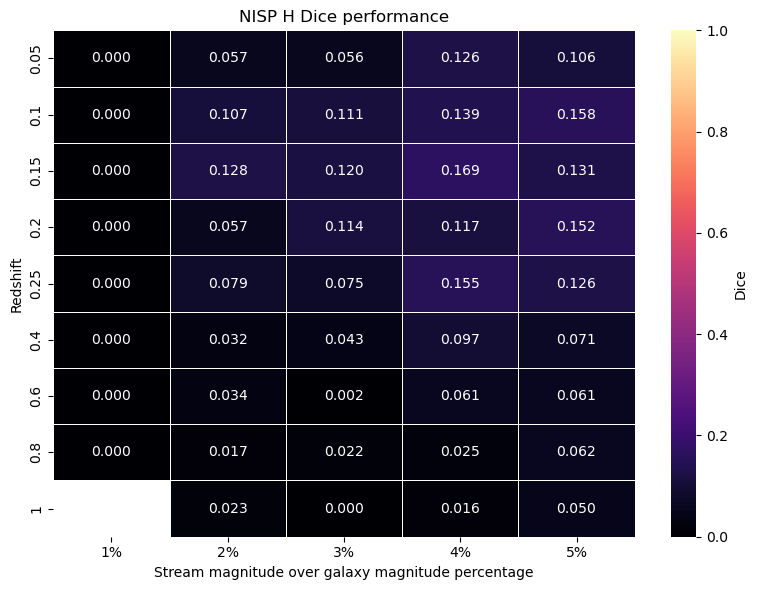

In [67]:
matrix_data_dice = {redshift: {key: np.nanmean(values) for key, values in subdict.items()} 
               for redshift, subdict in dice_results_redshift_with_mag_stream_percentage.items()}

labels_redshift = ['0.05','0.1','0.15','0.2','0.25','0.4','0.6','0.8','1']
labels_mag_percentage = ['1%','2%','3%','4%','5%']

# Convertir los datos en un DataFrame de Pandas
matrix_for_df = []
for redshift in labels_redshift:
    row = []
    for i, mag_label in enumerate(labels_mag_percentage, 1):  # 1, 2, 3, 4, 5
        if redshift in matrix_data_dice and i in matrix_data_dice[redshift]:
            row.append(matrix_data_dice[redshift][i])
        else:
            row.append(np.nan)
    matrix_for_df.append(row)

# Crear DataFrame
df = pd.DataFrame(matrix_for_df, index=labels_redshift, columns=labels_mag_percentage)

print(df)
# Crear el heatmap con anotaciones
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, fmt=".3f", cmap="magma", linewidths=0.5,
           cbar_kws={'label': 'Dice'}, vmin=0, vmax=1.0)

plt.xlabel('Stream magnitude over galaxy magnitude percentage')
plt.ylabel('Redshift')
plt.title("NISP H Dice performance")
plt.tight_layout()
plt.show()


/tmp/ipykernel_244577/3475454931.py:1: RuntimeWarning: Mean of empty slice
  matrix_data_iou = {redshift: {key: np.nanmean(values) for key, values in subdict.items()}


       1%        2%        3%        4%        5%
0.05  0.0  0.208575  0.290559  0.409119  0.449824
0.1   0.0  0.260137  0.419692  0.474314  0.545489
0.15  0.0  0.387139  0.408252  0.483641  0.500526
0.2   0.0  0.160307  0.397955  0.423843  0.482871
0.25  0.0  0.191103  0.268555  0.396854  0.446757
0.4   0.0  0.062500  0.115021  0.311508  0.225207
0.6   0.0  0.050000  0.037037  0.194444  0.207977
0.8   0.0  0.035714  0.036232  0.100386  0.151852
1     NaN  0.045455  0.000000  0.031250  0.145833


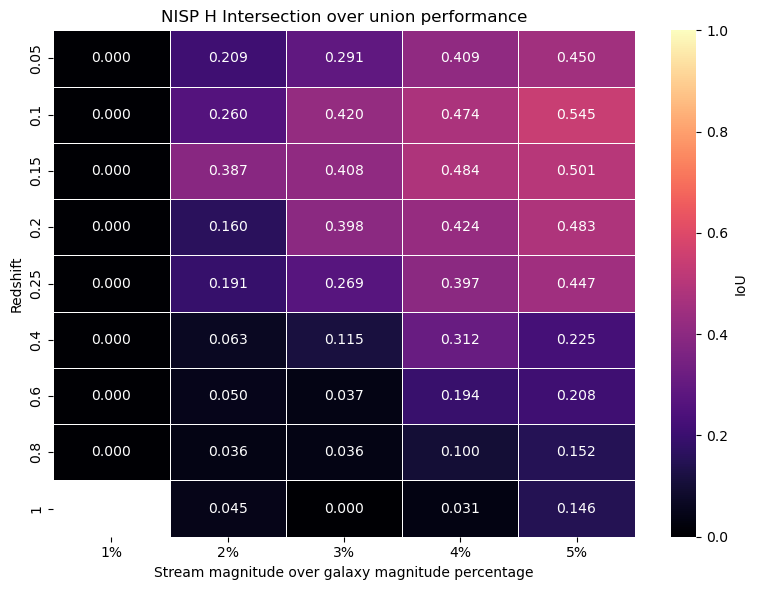

In [68]:
matrix_data_iou = {redshift: {key: np.nanmean(values) for key, values in subdict.items()} 
               for redshift, subdict in iou_results_redshift_with_mag_stream_percentage.items()}

labels_redshift = ['0.05','0.1','0.15','0.2','0.25','0.4','0.6','0.8','1']
labels_mag_percentage = ['1%','2%','3%','4%','5%']

# Convertir los datos en un DataFrame de Pandas
matrix_for_df = []
for redshift in labels_redshift:
    row = []
    for i, mag_label in enumerate(labels_mag_percentage, 1):  # 1, 2, 3, 4, 5
        if redshift in matrix_data_iou and i in matrix_data_iou[redshift]:
            row.append(matrix_data_iou[redshift][i])
        else:
            row.append(np.nan)
    matrix_for_df.append(row)

# Crear DataFrame
df = pd.DataFrame(matrix_for_df, index=labels_redshift, columns=labels_mag_percentage)

print(df)
# Crear el heatmap con anotaciones
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, fmt=".3f", cmap="magma", linewidths=0.5,
           cbar_kws={'label': 'IoU'}, vmin=0, vmax=1.0)

plt.xlabel('Stream magnitude over galaxy magnitude percentage')
plt.ylabel('Redshift')
plt.title("NISP H Intersection over union performance")
plt.tight_layout()
plt.show()